In [44]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,summarize)
from sklearn.tree import (DecisionTreeClassifier as DTC,DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,log_loss)
from sklearn.ensemble import (RandomForestRegressor as RF,GradientBoostingRegressor as GBR,
                             GradientBoostingClassifier as GBC)
from sklearn.linear_model import LogisticRegression 
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

In [46]:
Boston=load_data("Boston")

In [48]:
model = MS(Boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(Boston)
feature_names = list(D.columns)
X = np.asarray(D)

In [50]:
(X_train, X_test, y_train, y_test) = skm.train_test_split(X,Boston['medv'],test_size=0.5,
                                                          random_state=30)

In [52]:
k=0
MSE=np.zeros((30,3))
for t in range(10,600,20):
    RF_Boston1=RF(max_features=1.0,n_estimators=t,random_state=30).fit(X_train,y_train)
    RF_Boston2=RF(max_features=0.5,n_estimators=t,random_state=30).fit(X_train,y_train)
    RF_Boston3=RF(max_features='sqrt',n_estimators=t,random_state=30).fit(X_train,y_train)
    ypred1=RF_Boston1.predict(X_test)
    ypred2=RF_Boston2.predict(X_test)
    ypred3=RF_Boston3.predict(X_test)
    MSE[k,0]=np.mean((y_test - ypred1)**2)
    MSE[k,1]=np.mean((y_test - ypred2)**2)
    MSE[k,2]=np.mean((y_test - ypred3)**2)
    k+=1

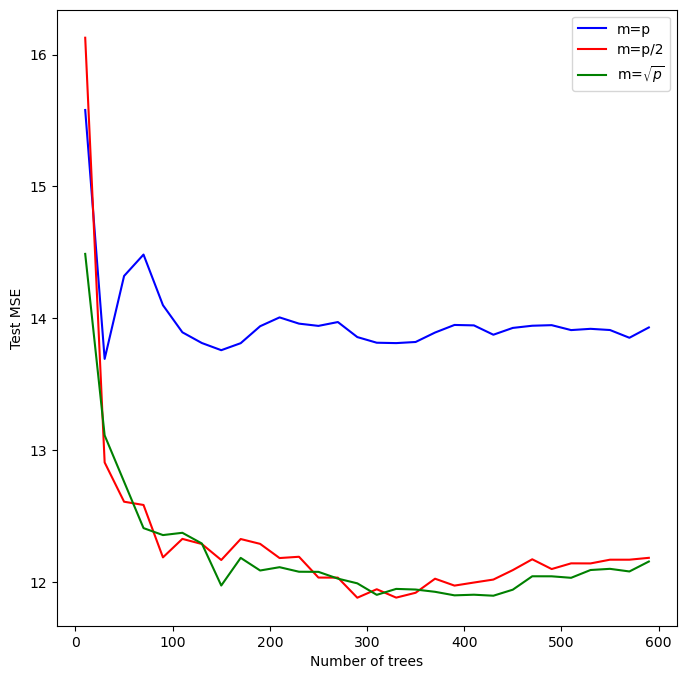

In [53]:
plot_idx = np.arange(10,600,20)
ax = subplots(figsize=(8,8))[1]
ax.plot(plot_idx,MSE[:,0],'b',label='m=p')
ax.plot(plot_idx,MSE[:,1],'r',label='m=p/2')
#ax.plot(plot_idx,MSE[:,2],'g',label='m=$\sqrt{p}$')
ax.plot(plot_idx,MSE[:,2],'g',label=r'm=$\sqrt{p}$')
ax.set_xlabel('Number of trees')
ax.set_ylabel('Test MSE')
ax.legend();

In [54]:
Carseats=load_data('Carseats')

In [55]:
model = MS(Carseats.columns.drop('Sales'), intercept=False)
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D)

In [56]:
(X_train, X_test, y_train, y_test) = skm.train_test_split(X,Carseats['Sales'],test_size=0.5,
                                                          random_state=30)

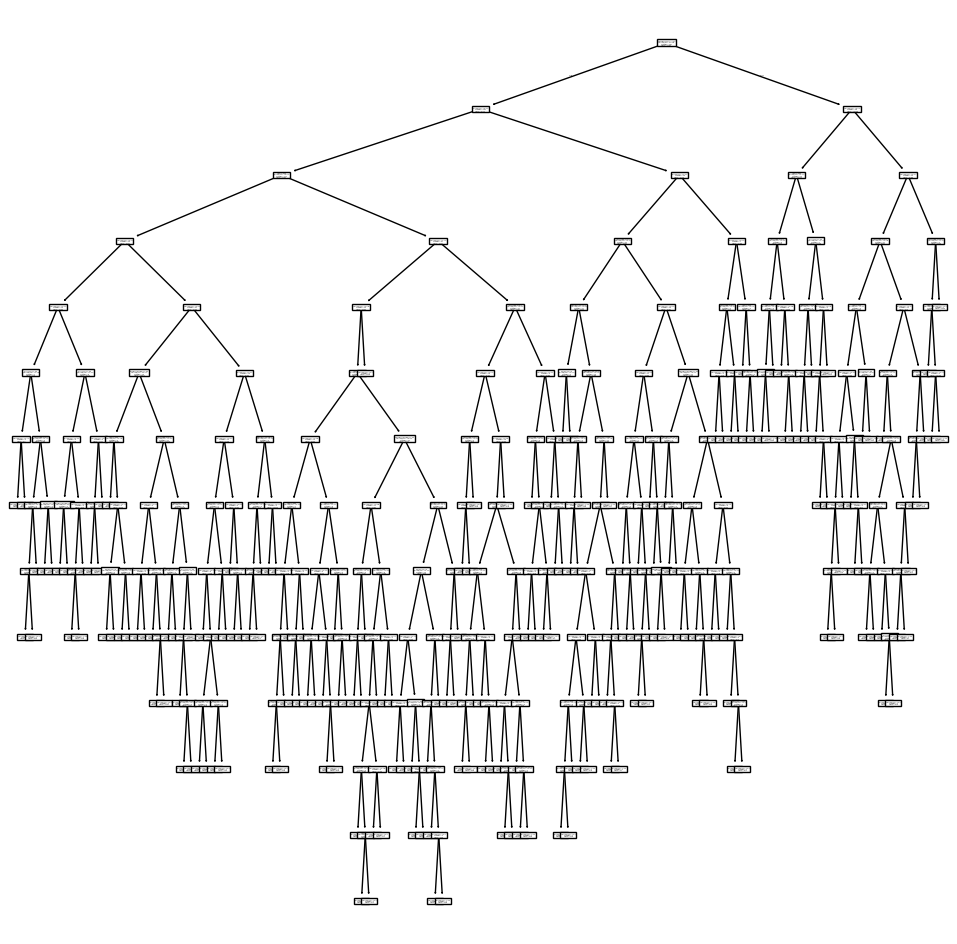

In [57]:
reg = DTR()
result=reg.fit(X_train, y_train)
ax = subplots(figsize=(12,12))[1]
plot_tree(reg,feature_names=feature_names,ax=ax);

In [58]:
ypred=result.predict(X_test)
MSE=np.mean((ypred-y_test)**2)
MSE

5.451075

In [59]:
result.get_depth()

13

In [60]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5,shuffle=True,random_state=35)
grid = skm.GridSearchCV(reg,{'ccp_alpha': ccp_path.ccp_alphas},refit=True,cv=kfold,
                        scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)

In [61]:
grid.best_estimator_.ccp_alpha

0.10074276955128336

In [62]:
best_model=grid.best_estimator_
pruning_MSE=np.mean((y_test-best_model.predict(X_test))**2)
pruning_MSE

5.08291504518195

In [63]:
bag_seats = RF(max_features=X_train.shape[1], random_state=36)
bag_seats.fit(X_train, y_train)

RandomForestRegressor(max_features=11, random_state=36)

In [64]:
bag_MSE=np.mean((y_test - bag_seats.predict(X_test))**2)
bag_MSE

2.6145821358499997

In [65]:
df=pd.DataFrame({'importance':bag_seats.feature_importances_},index=feature_names)
df.sort_values(by='importance', ascending=False)

,importance
Price,0.291835
ShelveLoc[Good],0.211079
Income,0.103316
Age,0.098761
CompPrice,0.095919
Advertising,0.056774
ShelveLoc[Medium],0.050990
Population,0.044953
Education,0.031706
Urban[Yes],0.009492


In [66]:
RF_MSE=np.zeros((1,3))
RF_seats1=RF(max_features=1.0,random_state=0).fit(X_train,y_train)
RF_seats2=RF(max_features=0.5,random_state=0).fit(X_train,y_train)
RF_seats3=RF(max_features='sqrt',random_state=0).fit(X_train,y_train)
ypred1=RF_seats1.predict(X_test)
ypred2=RF_seats2.predict(X_test)
ypred3=RF_seats3.predict(X_test)
RF_MSE[0,0]=np.mean((y_test - ypred1)**2)
RF_MSE[0,1]=np.mean((y_test - ypred2)**2)
RF_MSE[0,2]=np.mean((y_test - ypred3)**2)

In [67]:
RF_MSE

array([[2.57109663, 2.75792513, 3.04815656]])

In [68]:
df=pd.DataFrame({'importance':RF_seats1.feature_importances_},index=feature_names)
df.sort_values(by='importance', ascending=False)

,importance
Price,0.296556
ShelveLoc[Good],0.214089
Income,0.101554
CompPrice,0.100222
Age,0.089137
Advertising,0.056200
ShelveLoc[Medium],0.051287
Population,0.045874
Education,0.031734
Urban[Yes],0.008122


In [69]:
Caravan=load_data('Caravan')

In [70]:
Caravan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 86 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   MOSTYPE   5822 non-null   int64   
 1   MAANTHUI  5822 non-null   int64   
 2   MGEMOMV   5822 non-null   int64   
 3   MGEMLEEF  5822 non-null   int64   
 4   MOSHOOFD  5822 non-null   int64   
 5   MGODRK    5822 non-null   int64   
 6   MGODPR    5822 non-null   int64   
 7   MGODOV    5822 non-null   int64   
 8   MGODGE    5822 non-null   int64   
 9   MRELGE    5822 non-null   int64   
 10  MRELSA    5822 non-null   int64   
 11  MRELOV    5822 non-null   int64   
 12  MFALLEEN  5822 non-null   int64   
 13  MFGEKIND  5822 non-null   int64   
 14  MFWEKIND  5822 non-null   int64   
 15  MOPLHOOG  5822 non-null   int64   
 16  MOPLMIDD  5822 non-null   int64   
 17  MOPLLAAG  5822 non-null   int64   
 18  MBERHOOG  5822 non-null   int64   
 19  MBERZELF  5822 non-null   int64   
 20  MBERBOER

In [71]:
Caravan

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5817,36,1,1,2,8,0,6,1,2,1,...,0,0,0,1,0,0,0,0,0,No
5818,35,1,4,4,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
5819,33,1,3,4,8,0,6,0,3,5,...,0,0,0,1,0,0,0,0,0,Yes
5820,34,1,3,2,8,0,7,0,2,7,...,0,0,0,0,0,0,0,0,0,No


In [72]:
model = MS(Caravan.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(Caravan)
feature_names = list(D.columns)
X = np.asarray(D)

In [73]:
y=Caravan['Purchase']
(X_train, X_test, y_train, y_test) = skm.train_test_split(X,y,train_size=1000,random_state=1)

In [74]:
boost_Caravan = GBC(n_estimators=1000,learning_rate=0.01,random_state=3)
boost_Caravan.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000,
                           random_state=3)

In [75]:
feature_imp = pd.DataFrame({'importance':boost_Caravan.feature_importances_},index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
MGODOV,0.061780
PPERSAUT,0.060080
AFIETS,0.056704
APERSAUT,0.055635
MBERARBG,0.038662
...,...
AVRAAUT,0.000000
PPERSONG,0.000000
ABESAUT,0.000000
PZEILPL,0.000000


In [76]:
ypred=boost_Caravan.predict_proba(X_test)

In [77]:
ypred=ypred[:,1]

In [78]:
ypred=np.where(ypred>0.2,'Yes','No')
confusion_boost = confusion_table(y_test, ypred)

In [79]:
confusion_boost

Truth,No,Yes
Predicted,,
No,4293,240
Yes,240,49


In [80]:
49/(240+49)

0.1695501730103806

In [81]:
(Caravan_train, Caravan_test) = skm.train_test_split(Caravan,train_size=1000,random_state=1)

In [82]:
design = MS(Caravan_train.columns.drop(['Purchase']),intercept=False)
X_train_lk = design.fit_transform(Caravan_train)
y_train_lk = Caravan_train.Purchase == 'Yes'
glm = sm.GLM(y_train_lk,X_train_lk,family=sm.families.Binomial())
results = glm.fit()

In [83]:
ypred_logit=np.where(results.predict(X_test)>0.2,'Yes','No')
confusion_logit = confusion_table(y_test, ypred_logit)

In [84]:
confusion_logit

Truth,No,Yes
Predicted,,
No,4190,343
Yes,235,54


In [85]:
54/(54+235)

0.18685121107266436

In [86]:
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_lk, y_train_lk)
knn_pred_prob = knn.predict_proba(X_test)[:,1]
knn_pred=np.where(knn_pred_prob>0.2,'Yes','No')
confusion_table(knn_pred, y_test)

C:\Users\u\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Truth,No,Yes
Predicted,,
No,4384,253
Yes,149,36


In [87]:
36/(149+36)

0.1945945945945946

In [88]:
Weekly=load_data('Weekly')

In [89]:
Weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [90]:
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [91]:
model = MS(Weekly.columns.drop(['Direction','Today']), intercept=False)
D = model.fit_transform(Weekly)
feature_names = list(D.columns)
X = np.asarray(D)

In [92]:
y=Weekly['Direction']
(X_train, X_test, y_train, y_test) = skm.train_test_split(X,y,train_size=0.7,random_state=30)

In [93]:
boost_Weekly = GBC(n_estimators=1000,learning_rate=0.001,random_state=1,max_depth=1)
boost_Weekly.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.001, max_depth=1, n_estimators=1000,
                           random_state=1)

In [94]:
ypred = boost_Weekly.predict(X_test)

In [95]:
confusion_boost=confusion_table(y_test,ypred)

In [96]:
confusion_boost

Truth,Down,Up
Predicted,,
Down,1,142
Up,0,184


In [97]:
142 / np.sum(confusion_boost.values)

0.43425076452599387

In [98]:
bag_weekly = RF(max_features=X_train.shape[1], random_state=1)
y_train=np.where(y_train=='Up',1,0)
bag_weekly.fit(X_train, y_train)

RandomForestRegressor(max_features=7, random_state=1)

In [99]:
ypred = bag_weekly.predict(X_test)
y_pred=np.where(ypred>0.5,'Up','Down')
confusion_bagging=confusion_table(y_test,y_pred)

In [100]:
confusion_bagging

Truth,Down,Up
Predicted,,
Down,59,84
Up,60,124


In [101]:
(60+84)/np.sum(confusion_bagging.values)

0.44036697247706424

In [102]:
RF_weekly=RF(max_features='sqrt',random_state=30).fit(X_train,y_train)

In [103]:
ypred = RF_weekly.predict(X_test)
y_pred=np.where(ypred>0.5,'Up','Down')
confusion_RF=confusion_table(y_test,y_pred)

In [104]:
confusion_RF

Truth,Down,Up
Predicted,,
Down,55,88
Up,59,125


In [105]:
(88+59)/np.sum(confusion_RF.values)

0.44954128440366975

In [106]:
glm = sm.GLM(y_train,X_train,family=sm.families.Binomial())
results = glm.fit_regularized(method='elastic_net', alpha=0.1, L1_wt=0, disp=False)

In [107]:
ypred = results.predict(X_test)
y_pred=np.where(ypred>0.5,'Up','Down')
confusion_logit=confusion_table(y_test,y_pred)

In [108]:
confusion_logit

Truth,Down,Up
Predicted,,
Down,17,126
Up,18,166


In [109]:
(18+121)/np.sum(confusion_logit.values)

0.42507645259938837